# Events and zones

Scripted grid and market events, and the four illustrative network zones every EV belongs to.
Every price, payment and headroom here is synthetic or illustrative (decision 0004 items 55 and
56; trading contract v1 §2, §3): none is a forecast, a DFS rate or a DNO tariff.

**The idea in one paragraph.** An event is a scenario, not a draw: it is the same in every
simulated week, layered on top of the random weather the market already has (notebook 03). A
**price shock** preset adds one more trapezoid of net demand, either **known day-ahead** (it is
already in the day-ahead auction the smart charger plans against) or a **surprise** (revealed only
a little before it starts, so it moves intraday and imbalance but never the plan). A **grid
request** preset (turn-down or turn-up) never touches the price: it adds a penalty or bonus
straight into the smart planner's ranking for EVs in scope, and pays for whatever turn-down or
turn-up actually lands against the settlement baseline. A **control outage** raises the chance a
session ignores its plan altogether. Every EV also belongs to one of four illustrative network
zones, each with an optional reported (never enforced) import headroom.

Because `model/events.py` draws no random number, running the same seed with and without a preset
gives the same population, the same trips and (for a request) the same prices: **common random
numbers**, so any difference is the event, not noise.

The notebook calls the same functions the app does (`forecast.run_forecast_from_assumptions`,
`model/events.py`, `sampling.build_population`) and reads every quoted default from
`model/assumptions.py`'s `EVENT_PRESETS` and `ZONES`.

**Sections**

1. Scripted events and presets
2. Known versus surprise price shocks, and the reveal rule
3. Grid turn-down and turn-up requests
4. A control outage
5. Zones: exact-count permutation and reported headroom
6. With and without a preset, same seed: common random numbers
7. Sanity checks
8. Limitations

In [1]:
# --- MODEL IMPORTS (one cell) -----------------------------------------------
from datetime import date

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from axle_studio.model import assumptions
from axle_studio.model import events as model_events
from axle_studio.model.assumptions import ZONE_IDS, ZONE_LABELS
from axle_studio.model.forecast import (
    build_study_slots,
    run_forecast,
    run_forecast_from_assumptions,
)
from axle_studio.model.sampling import build_population
from axle_studio.ui.style import ARCHETYPE_COLOURS, PATH_STYLES, apply_notebook_style

# "notebook_connected" embeds only the figure data and loads plotly.js from a CDN, which keeps the
# committed notebook small. GitHub does not run that script, so every chart has a table under it.
pio.renderers.default = "notebook_connected"
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 100)
LONDON = "Europe/London"
# The zones have no meaning in common with the six driver archetypes; this only reuses the
# archetype hue set (ui/style.py) for a second, unrelated four-way category, so zone colours stay
# consistent with the rest of the dark theme instead of inventing a new palette here.
ZONE_COLOURS = dict(zip(ZONE_IDS, ARCHETYPE_COLOURS[:4], strict=False))

## Try it

The runs are small so the notebook stays fast (a few seconds each); raise `VEHICLE_COUNT` and
`WORLD_COUNT` for steadier numbers. `EVENT_PRESETS` below is the *module's* dict of every
scripted scenario the app can add; the notebook runs a handful of them one at a time so each
section isolates one mechanism.

In [2]:
START_LOCAL_DATE = date(2026, 1, 12)  # the London date the seven study nights start (a Monday)
VEHICLE_COUNT = 50
WORLD_COUNT = 10  # simulated weeks
VALUES = {"vehicle_count": VEHICLE_COUNT, "evaluation_world_count": WORLD_COUNT}

base = run_forecast_from_assumptions(START_LOCAL_DATE, values=VALUES, event_presets=())
pd.DataFrame(
    [
        {
            "policy_id": base.policy_id,
            "evidence_kind": base.evidence_kind,
            "vehicles": base.vehicle_count,
            "simulated weeks": base.world_count,
            "zone ids": base.zone_ids,
        }
    ]
)

,policy_id,evidence_kind,vehicles,simulated weeks,zone ids
0,explicit_synthetic_wholesale_v1,illustrative_synthetic,50,10,"(zone_1, zone_2, zone_3, zone_4)"


## 1. Scripted events and presets

`model/events.py` owns the events table (`EVENT_COLUMNS`), its validation
(`validate_events`) and the translation of each enabled row into what the rest of the model
reads: net-demand profiles for price shocks, a planner price adjustment and a trading mask for
requests, and a non-response probability for an outage. It draws no random number itself
(module docstring): an event is a scenario applied identically in every simulated week.

`assumptions.EVENT_PRESETS` holds the illustrative scenario values behind each preset id; a run
takes a sequence of preset ids (`run_forecast_from_assumptions(event_presets=[...])`), which is
what the events editor in the app will drive. Two presets (not shown below) expand to several
rows for one study: `cold_still_week` repeats the cold evening every night, and
`sunny_negative_weekend` places one row on each Saturday and Sunday the study touches.

In [3]:
def _notice_label(preset: dict) -> str:
    if preset["notice"] == "day_ahead":
        return "day_ahead"
    return f"short ({preset['notice_minutes']} min)"


preset_rows = [
    {
        "preset id": preset_id,
        "label": preset["label"],
        "event type": preset["event_type"],
        "scope": preset["scope"],
        "notice": _notice_label(preset),
        "size": preset["size"],
    }
    for preset_id, preset in assumptions.EVENT_PRESETS.items()
    if preset["night_index"] is not None  # the two multi-row presets are shown separately below
]
pd.DataFrame(preset_rows)

,preset id,label,event type,scope,notice,size
0,cold_still_evening,Cold still evening (known day-ahead),price_shock_known,national,day_ahead,4.0
1,surprise_evening_spike,Surprise evening spike,price_shock_surprise,national,short (90 min),3.0
2,dfs_turn_down,Demand-flexibility turn-down called day-ahead,turn_down,national,day_ahead,NaN
3,local_turn_up,Local turn-up in one zone,turn_up,zone_2,day_ahead,NaN
4,charger_control_outage,Charger control outage: plans not followed,control_outage,national,short (0 min),0.5


The two presets left out above expand to several rows for one study rather than naming a single
night: `cold_still_week` repeats the cold evening every session night, and
`sunny_negative_weekend` places one row on each Saturday and Sunday the study's own dates touch
(`events.preset_rows`, which the table above cannot show without picking a study).

## 2. Known versus surprise price shocks, and the reveal rule

`cold_still_evening` adds +4 GW to net demand, known day-ahead: the smart charger sees the dearer
evening in the day-ahead prices it plans against, exactly like any other day-ahead price move.
`surprise_evening_spike` adds +3 GW, but as a **surprise**: nothing in the day-ahead price changes
(no plan ever sees it coming), and it only shows up in the intraday and imbalance prices once
revealed. Both use the same trapezoid shape as the stochastic shocks notebook 03 covers in depth
(item 56): ramp up over the first quarter of the window, hold, ramp down over the last quarter.

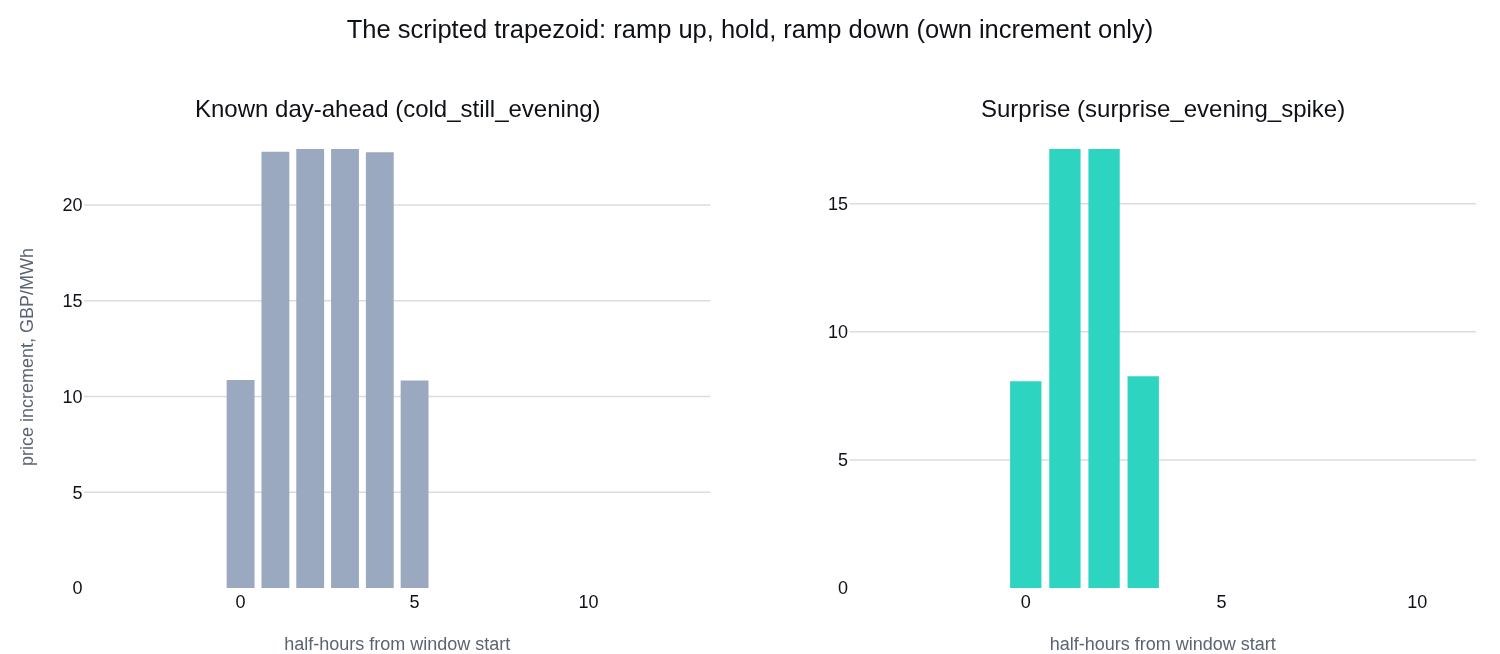

In [4]:
known = run_forecast_from_assumptions(
    START_LOCAL_DATE, values=VALUES, event_presets=["cold_still_evening"]
)
surprise = run_forecast_from_assumptions(
    START_LOCAL_DATE, values=VALUES, event_presets=["surprise_evening_spike"]
)

shock_figure = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Known day-ahead (cold_still_evening)", "Surprise (surprise_evening_spike)"],
)
for col, (result, colour) in enumerate(
    ((known, PATH_STYLES["normal"]["color"]), (surprise, PATH_STYLES["selected"]["color"])), start=1
):
    rows = result.event_response_bands.query(
        "series == 'market' and metric == 'price_increment_gbp_per_mwh'"
    ).sort_values("relative_slot")
    shock_figure.add_trace(
        go.Bar(
            x=rows["relative_slot"],
            y=rows["p50"].round(2),
            marker_color=np.where(rows["in_window"], colour, "#5B6472"),
            showlegend=False,
        ),
        row=1,
        col=col,
    )
shock_figure.update_xaxes(title_text="half-hours from window start")
shock_figure.update_yaxes(title_text="price increment, GBP/MWh", col=1)
shock_figure.update_layout(
    title="The scripted trapezoid: ramp up, hold, ramp down (own increment only)"
)
apply_notebook_style(shock_figure, height=360)

In [5]:
def _window_table(result, label: str) -> pd.DataFrame:
    rows = result.event_response_bands.query(
        "series == 'market' and metric == 'price_increment_gbp_per_mwh' and in_window"
    ).sort_values("relative_slot")
    return pd.DataFrame(
        {
            "preset": label,
            "London": rows["interval_start_london"].dt.strftime("%a %H:%M"),
            "price increment, P50 GBP/MWh": rows["p50"].round(2),
        }
    )


pd.concat(
    [
        _window_table(known, "cold_still_evening (known)"),
        _window_table(surprise, "surprise_evening_spike (surprise)"),
    ],
    ignore_index=True,
)

,preset,London,"price increment, P50 GBP/MWh"
0,cold_still_evening (known),Wed 16:30,10.86
1,cold_still_evening (known),Wed 17:00,22.78
2,cold_still_evening (known),Wed 17:30,22.92
3,cold_still_evening (known),Wed 18:00,22.92
4,cold_still_evening (known),Wed 18:30,22.75
5,cold_still_evening (known),Wed 19:00,10.83
6,surprise_evening_spike (surprise),Fri 17:00,8.07
7,surprise_evening_spike (surprise),Fri 17:30,17.13
8,surprise_evening_spike (surprise),Fri 18:00,17.13
9,surprise_evening_spike (surprise),Fri 18:30,8.26


**The reveal rule.** A scripted surprise is revealed `notice_minutes` before its window starts
(`events.scripted_surprise_reveal_hours`); half-hour `k` of the window itself closes
`trading.gate_closure_minutes` before it starts, so a slot further into the window has already had
the announcement sit for longer relative to its own, later gate closure. The table below reads
that function directly, alongside the raw net-demand profile it is revealing
(`events.scripted_shock_profiles`), for `surprise_evening_spike`'s own window.

In [6]:
gate_closure_minutes = assumptions.TRADING["gate_closure_minutes"].value
slot_count = len(surprise.study_slots)
_, surprise_gw = model_events.scripted_shock_profiles(
    surprise.events, surprise.study_slots, slot_count
)
reveal_hours = model_events.scripted_surprise_reveal_hours(
    surprise.events, surprise.study_slots, slot_count, gate_closure_minutes=gate_closure_minutes
)
window = np.flatnonzero(surprise_gw != 0)
pd.DataFrame(
    {
        "London": surprise.study_slots["interval_start_london"]
        .iloc[window]
        .dt.strftime("%a %H:%M"),
        "surprise, GW": surprise_gw[window],
        "revealed, hours before that slot's own gate closure": reveal_hours[window],
    }
).assign(
    **{"notice given (minutes before window start)": int(surprise.events["notice_minutes"].iat[0])}
)

,London,"surprise, GW","revealed, hours before that slot's own gate closure",notice given (minutes before window start)
202,Fri 17:00,1.5,0.0,90
203,Fri 17:30,3.0,1.0,90
204,Fri 18:00,3.0,1.0,90
205,Fri 18:30,1.5,2.0,90


## 3. Grid turn-down and turn-up requests

`dfs_turn_down` asks the fleet to reduce import for an hour, paid per MWh delivered against the
settlement baseline; `local_turn_up` asks zone B alone to import more, for two hours, also paid.
Neither changes a single price: `planner_adjustments` adds the payment straight into the smart
plan's ranking inside the window, for EVs in scope only, and only for plans made at or after the
request's notice instant (no plan is ever surprised by a request it could not have known).
`event_response_bands`' `difference` series (selected minus normal, paired inside each simulated
week) shows the shape: import falls inside the window and can **rebound** just after it, which the
contract reports rather than penalises.

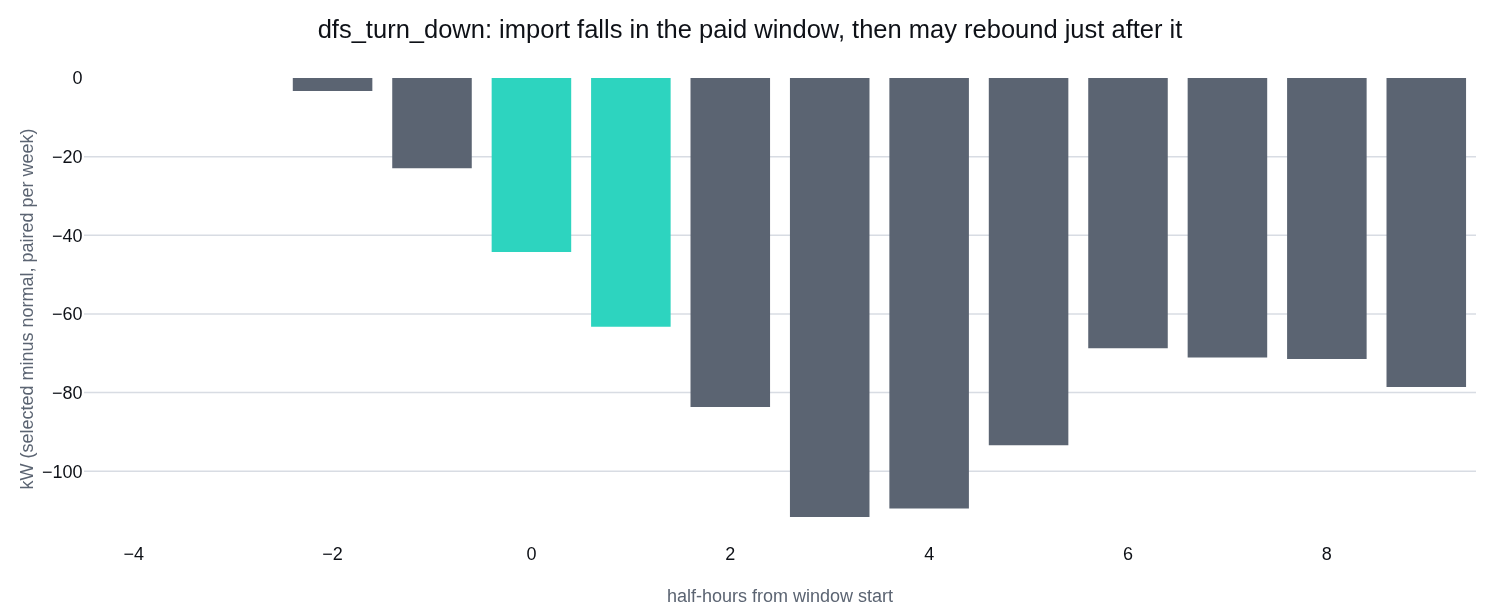

In [7]:
turn_down = run_forecast_from_assumptions(
    START_LOCAL_DATE, values=VALUES, event_presets=["dfs_turn_down"]
)

request_figure = go.Figure()
diff = turn_down.event_response_bands.query(
    "series == 'difference' and metric == 'home_import_kw'"
).sort_values("relative_slot")
request_figure.add_trace(
    go.Bar(
        x=diff["relative_slot"],
        y=diff["p50"].round(2),
        marker_color=np.where(diff["in_window"], PATH_STYLES["selected"]["color"], "#5B6472"),
        name="Smart minus unmanaged import (P50)",
    )
)
request_figure.update_layout(
    title="dfs_turn_down: import falls in the paid window, then may rebound just after it",
    xaxis_title="half-hours from window start",
    yaxis_title="kW (selected minus normal, paired per week)",
    showlegend=False,
)
apply_notebook_style(request_figure, height=360)

In [8]:
diff_table = diff.assign(London=diff["interval_start_london"].dt.strftime("%a %H:%M"))
diff_table[["relative_slot", "London", "in_window", "p10", "p50", "p90"]].round(2)

,relative_slot,London,in_window,p10,p50,p90
70,-4,Tue 15:30,False,-7.00,0.00,0.00
71,-3,Tue 16:00,False,-9.75,0.00,0.00
72,-2,Tue 16:30,False,-16.80,-3.28,0.00
73,-1,Tue 17:00,False,-36.49,-22.96,-12.60
74,0,Tue 17:30,True,-60.61,-44.26,-27.30
75,1,Tue 18:00,True,-85.06,-63.27,-42.55
76,2,Tue 18:30,False,-110.98,-83.68,-59.98
77,3,Tue 19:00,False,-139.49,-111.62,-69.21
78,4,Tue 19:30,False,-144.48,-109.46,-56.53
79,5,Tue 20:00,False,-122.23,-93.41,-10.12


In [9]:
ledger = turn_down.trading_ledger_summary.query(
    "strategy == 'full' and metric == 'grid_event_payment_gbp' and night_index.isna()",
    engine="python",
)
payment_gbp_per_mwh = float(turn_down.events["payment_gbp_per_mwh"].iat[0])
pd.DataFrame(
    [
        {
            "preset": "dfs_turn_down",
            "payment rate, illustrative GBP/MWh": payment_gbp_per_mwh,
            "grid_event_payment_gbp per week, P10": ledger["p10"].iat[0],
            "grid_event_payment_gbp per week, P50": ledger["p50"].iat[0],
            "grid_event_payment_gbp per week, P90": ledger["p90"].iat[0],
        }
    ]
).round(2)

,preset,"payment rate, illustrative GBP/MWh","grid_event_payment_gbp per week, P10","grid_event_payment_gbp per week, P50","grid_event_payment_gbp per week, P90"
0,dfs_turn_down,500.0,26.29,29.7,34.12


`grid_event_payment_gbp` is the world-first sum of `min(max(0, B - M), cap) / 1000 x payment` over
every window half-hour, done inside each simulated week before the P10/P50/P90 above are taken
(`events.event_delivery`); the chart's P50 line is the shape of that calculation, not a number
that itself sums to the ledger row.

`local_turn_up` is zone-scoped (zone B only), but a request pauses trading **fleet-wide** for its
window in this version (lead decision Q8, trading contract v1 §8): a simplification the contract
states directly rather than settling a zone-scoped request against a zone-scoped mask. The check
below reads that straight off `deviation_world_slot.settlement_open`.

In [10]:
turn_up = run_forecast_from_assumptions(
    START_LOCAL_DATE, values=VALUES, event_presets=["local_turn_up"]
)
request_row = model_events.event_slots(turn_up.events, turn_up.study_slots).iloc[0]
in_window = turn_up.deviation_world_slot["slot_index"].between(
    request_row["start_slot"], request_row["end_slot"] - 1
)
deviation = turn_up.deviation_world_slot
pd.DataFrame(
    [
        {
            "request scope": request_row["scope"],
            "settlement_open, inside the window (expect 0: fleet-wide pause)": deviation.loc[
                in_window, "settlement_open"
            ].mean(),
            "settlement_open, outside the window (expect 1)": deviation.loc[
                ~in_window, "settlement_open"
            ].mean(),
        }
    ]
)

,request scope,"settlement_open, inside the window (expect 0: fleet-wide pause)","settlement_open, outside the window (expect 1)"
0,zone_2,0.0,1.0


## 4. A control outage

`charger_control_outage` raises the chance that a session ignores its plan and just charges at
full power, for every plug-in in its window (`events.outage_probability`), regardless of zone.
Nothing about the population or the prices changes; only some sessions' realised import differs
from what they were planned to do, so the smart path's average price paid drifts up a little.

In [11]:
outage = run_forecast_from_assumptions(
    START_LOCAL_DATE, values=VALUES, event_presets=["charger_control_outage"]
)
slot_count = len(outage.study_slots)
probability = model_events.outage_probability(
    outage.events, outage.study_slots, len(ZONE_IDS), slot_count
)
affected = np.flatnonzero(probability.any(axis=0))
outage_rate = float(outage.events["size"].iat[0])
outage_summary = pd.DataFrame(
    [
        {
            "outage window starts (London)": outage.study_slots["interval_start_london"]
            .iat[affected[0]]
            .strftime("%a %H:%M"),
            "outage window ends (London)": (
                outage.study_slots["interval_start_london"].iat[affected[-1]]
                + pd.Timedelta(minutes=30)
            ).strftime("%a %H:%M"),
            "share of plug-ins ignoring their plan (record)": outage_rate,
            "average smart-path price, no events, GBP/MWh": base.smart_charging_world[
                "selected_average_price_gbp_per_mwh"
            ].mean(),
            "average smart-path price, with the outage, GBP/MWh": outage.smart_charging_world[
                "selected_average_price_gbp_per_mwh"
            ].mean(),
        }
    ]
).round(3)
outage_summary

,outage window starts (London),outage window ends (London),share of plug-ins ignoring their plan (record),"average smart-path price, no events, GBP/MWh","average smart-path price, with the outage, GBP/MWh"
0,Thu 15:00,Fri 03:00,0.5,46.225,48.707


## 5. Zones: exact-count permutation and reported headroom

Every EV is placed in one of four illustrative zones with no geography
(`assumptions.ZONE_IDS`, `ZONE_LABELS`), by exact counts (largest remainder on the shares, ties
to the lower zone index — the same method the six driver cohorts use) and then one permutation,
independent of cohort. It is the third of five population draws, not the last: cohort permutation,
personal mileage multipliers, **zone permutation**, control-group permutation, then the
manufacturer permutation (trading contract v1 §3, §10.1d). The two draws after it each take
exactly `vehicle_count` random numbers whatever the zone shares are, so editing a zone share still
moves no other channel — it only changes which zone each of those same numbers lands an EV in. The
call below runs `sampling.build_population` on its own, with no Monte Carlo simulation needed to
see the assignment; it stops before the control-group and manufacturer draws, which belong to
`forecast.run_forecast` rather than to zones.

In [12]:
resolved = assumptions.resolve_values(VALUES)
settings = assumptions.run_settings(resolved, START_LOCAL_DATE)
fixture = assumptions.cohort_fixture(resolved)
inputs = assumptions.forecast_inputs(
    resolved, warmup_days=settings.warmup_days, study_days=settings.study_days
)
# The mileage draws below are drawn before the zone permutation inside build_population, so they
# must be passed here too: leaving them out would silently change how much of the random stream
# the zone draw consumes, and the assignment would no longer match a real run's own.
mileage_kwargs = {
    "daily_miles_cv_by_cohort": inputs["daily_miles_cv_by_cohort"],
    "personal_mileage_cv_by_cohort": inputs["personal_mileage_cv_by_cohort"],
}

default_shares = tuple(assumptions.ZONES[f"share.{zone_id}"].value for zone_id in ZONE_IDS)
rng_default = np.random.default_rng(assumptions.SIMULATION["seed"].value)
units_default = build_population(
    settings, fixture, rng_default, zone_shares=default_shares, **mileage_kwargs
)
# The next population draw after zones (the control-group permutation, contract §3, §10.1d): drawn
# here too, from the same rng, so editing a zone share can be checked against it below.
control_order_default = rng_default.permutation(settings.vehicle_count)

skewed_shares = (0.5, 0.2, 0.2, 0.1)
rng_skewed = np.random.default_rng(assumptions.SIMULATION["seed"].value)
units_skewed = build_population(
    settings, fixture, rng_skewed, zone_shares=skewed_shares, **mileage_kwargs
)
control_order_skewed = rng_skewed.permutation(settings.vehicle_count)

zone_counts = (
    pd.DataFrame(
        {
            f"default shares {default_shares}": units_default["zone_id"].value_counts(),
            f"skewed shares {skewed_shares}": units_skewed["zone_id"].value_counts(),
        }
    )
    .reindex(list(ZONE_IDS))
    .rename(index=ZONE_LABELS)
)
zone_counts

,"default shares (0.25, 0.25, 0.25, 0.25)","skewed shares (0.5, 0.2, 0.2, 0.1)"
zone_id,,
Zone A,13,25
Zone B,13,10
Zone C,12,10
Zone D,12,5


In [13]:
pd.DataFrame(
    [
        {
            "check": "exact counts sum to the fleet size (both share sets)",
            "value": bool(
                zone_counts.iloc[:, 0].sum() == VEHICLE_COUNT
                and zone_counts.iloc[:, 1].sum() == VEHICLE_COUNT
            ),
        },
        {
            "check": "editing zone shares moves no other draw (cohort assignment unchanged)",
            "value": bool(units_default["cohort_id"].equals(units_skewed["cohort_id"])),
        },
        {
            "check": "...nor the control-group permutation straight after it (contract §3, §10.1d)",
            "value": bool(np.array_equal(control_order_default, control_order_skewed)),
        },
        {
            "check": "this population's zone assignment matches a full run with the same seed",
            "value": bool(units_default["zone_id"].equals(base.units["zone_id"])),
        },
    ]
)

,check,value
0,exact counts sum to the fleet size (both share...,True
1,editing zone shares moves no other draw (cohor...,True
2,...nor the control-group permutation straight ...,True
3,this population's zone assignment matches a fu...,True


Headroom is reported against, never enforced by, the physics (contract §3). It is not yet
editable through the dialog, so the run below sets it directly (`run_forecast`, not
`run_forecast_from_assumptions`) for one zone, chosen below the zone's own P50 smart-path peak
from the `local_turn_up` run above so the report is not vacuous. The population and every price
are identical to `turn_up` (headroom draws no random number).

In [14]:
zone_b_peak_p50 = turn_up.zone_summary.query("zone_id == 'zone_2' and path_id == 'selected'")[
    "peak_kw_p50"
].iat[0]
demo_headroom_kw = (
    round(0.7 * zone_b_peak_p50 / 10) * 10
)  # illustrative: below the smart path's own peak

inputs["zone_headroom_kw"] = tuple(
    demo_headroom_kw if zone_id == "zone_2" else float("nan") for zone_id in ZONE_IDS
)
events_zone_b = model_events.event_table(
    ["local_turn_up"], build_study_slots(START_LOCAL_DATE, settings.study_days)
)
with_headroom = run_forecast(settings, fixture, **inputs, events=events_zone_b, model="action")

print(f"illustrative headroom set on zone B for this demo: {demo_headroom_kw:g} kW")
print("population identical to turn_up:", with_headroom.units.equals(turn_up.units))
with_headroom.zone_summary.query("zone_id == 'zone_2'")[
    [
        "path_id",
        "headroom_kw",
        "peak_kw_p10",
        "peak_kw_p50",
        "peak_kw_p90",
        "hours_above_headroom_p10",
        "hours_above_headroom_p50",
        "hours_above_headroom_p90",
    ]
].round(2)

illustrative headroom set on zone B for this demo: 50 kW
population identical to turn_up: True


,path_id,headroom_kw,peak_kw_p10,peak_kw_p50,peak_kw_p90,hours_above_headroom_p10,hours_above_headroom_p50,hours_above_headroom_p90
2,normal,50.0,44.46,49.00,56.0,0.00,0.0,1.0
3,selected,50.0,69.30,72.85,77.7,5.35,7.0,10.5


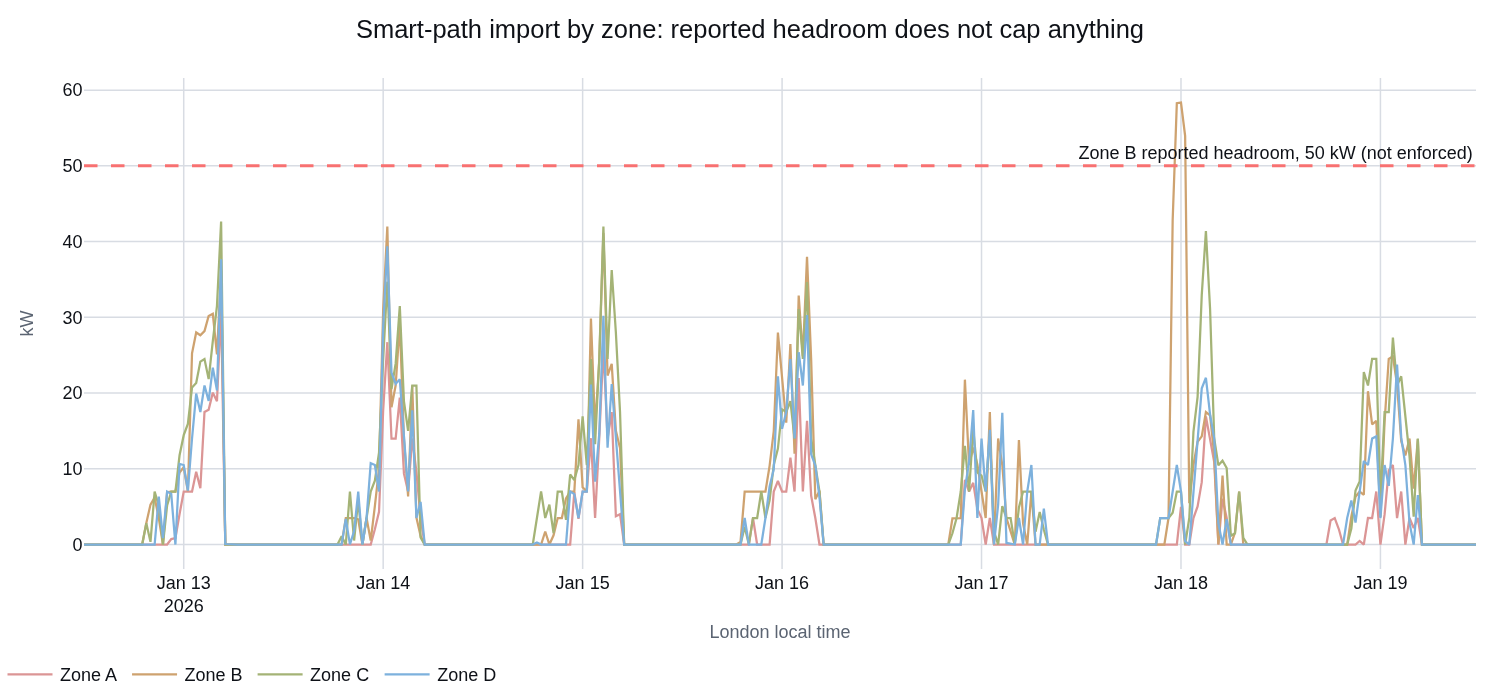

In [15]:
zone_figure = go.Figure()
for zone_id in ZONE_IDS:
    rows = with_headroom.zone_import_bands.query(
        "zone_id == @zone_id and path_id == 'selected'"
    ).sort_values("slot_index")
    zone_figure.add_trace(
        go.Scatter(
            x=rows["interval_start_utc"].dt.tz_convert(LONDON),
            y=rows["p50"].round(2),
            mode="lines",
            line={"color": ZONE_COLOURS[zone_id], "width": 1.5},
            name=ZONE_LABELS[zone_id],
        )
    )
headroom_kw = with_headroom.zone_import_bands.query("zone_id == 'zone_2'")["headroom_kw"].iat[0]
zone_figure.add_hline(
    y=headroom_kw,
    line={"color": "#F87171", "dash": "dash"},
    annotation_text=f"Zone B reported headroom, {headroom_kw:g} kW (not enforced)",
)
zone_figure.update_layout(
    title="Smart-path import by zone: reported headroom does not cap anything",
    xaxis_title="London local time",
    yaxis_title="kW",
)
apply_notebook_style(zone_figure, height=420)

In [16]:
example_zone_times = with_headroom.study_slots.query(
    "night_index == 0 and local_time_label in ['23:30', '00:00']"
)[["slot_index", "local_time_label"]]
zone_snapshot = with_headroom.zone_import_bands.query("path_id == 'selected'").merge(
    example_zone_times, on="slot_index"
)
(
    zone_snapshot.assign(zone_label=lambda frame: frame["zone_id"].map(ZONE_LABELS))
    .pivot(index="zone_label", columns="local_time_label", values="p50")
    .round(1)
    .rename_axis(index="Zone (smart path P50 kW)", columns="London time, night 0")
)

"London time, night 0",00:00,23:30
Zone (smart path P50 kW),,
Zone A,7.0,4.0
Zone B,10.2,9.5
Zone C,14.4,11.8
Zone D,10.5,10.6


## 6. With and without a preset, same seed: common random numbers

`model/events.py` draws no random number, so a run with a preset and a run without it, at the
same seed, share every random future: the same population, the same trips, the same weather. A
request changes nothing about prices (only the smart plan's ranking and the settlement), so
`base` and `dfs_turn_down` should be identical almost everywhere; a price shock changes prices, so
`base` and `cold_still_evening` should differ there and only there.

In [17]:
def _identical(a, b, column, path=None) -> bool:
    left, right = a.fleet_world_intervals, b.fleet_world_intervals
    if path is not None:
        left = left.query("path_id == @path")
        right = right.query("path_id == @path")
    return bool(np.allclose(left[column].to_numpy(), right[column].to_numpy()))


comparison = pd.DataFrame(
    [
        {
            "run": "dfs_turn_down (a request)",
            "population identical to base": bool(base.units.equals(turn_down.units)),
            "unmanaged import identical": _identical(base, turn_down, "home_import_kwh", "normal"),
            "day-ahead price identical": bool(
                np.allclose(
                    base.forecast_prices["wholesale_forecast_gbp_per_mwh"],
                    turn_down.forecast_prices["wholesale_forecast_gbp_per_mwh"],
                )
            ),
        },
        {
            "run": "cold_still_evening (a price shock)",
            "population identical to base": bool(base.units.equals(known.units)),
            "unmanaged import identical": _identical(base, known, "home_import_kwh", "normal"),
            "day-ahead price identical": bool(
                np.allclose(
                    base.forecast_prices["wholesale_forecast_gbp_per_mwh"],
                    known.forecast_prices["wholesale_forecast_gbp_per_mwh"],
                )
            ),
        },
    ]
)
comparison

,run,population identical to base,unmanaged import identical,day-ahead price identical
0,dfs_turn_down (a request),True,True,True
1,cold_still_evening (a price shock),True,True,False


A request leaves every column identical except the ledger and the smart plan's ranking inside its
own window; a price shock leaves the population and the unmanaged path alone but moves the
day-ahead price itself, because it is layered into net demand before the supply curve runs. Both
are exactly what "no random draw" predicts, not a coincidence of this run.

## 7. Sanity checks

In [18]:
known_window_increment = (
    known.event_response_bands.query(
        "series == 'market' and metric == 'price_increment_gbp_per_mwh' and in_window"
    )
    .sort_values("relative_slot")["p50"]
    .to_numpy()
)

checks = {
    "an empty events table (base) has no market shock rows from a preset": bool(
        (base.market_shocks["source"] == "scripted").sum() == 0
    ),
    "a request (dfs_turn_down) changes no random draw: population and prices match base": (
        bool(base.units.equals(turn_down.units))
        and _identical(base, turn_down, "home_import_kwh", "normal")
        and bool(
            np.allclose(
                base.forecast_prices["wholesale_forecast_gbp_per_mwh"],
                turn_down.forecast_prices["wholesale_forecast_gbp_per_mwh"],
            )
        )
    ),
    "a known price shock (cold_still_evening) moves the day-ahead price against base": not bool(
        np.allclose(
            base.forecast_prices["wholesale_forecast_gbp_per_mwh"],
            known.forecast_prices["wholesale_forecast_gbp_per_mwh"],
        )
    ),
    "a surprise shock leaves the day-ahead price exactly as base": bool(
        np.allclose(
            base.forecast_prices["wholesale_forecast_gbp_per_mwh"],
            surprise.forecast_prices["wholesale_forecast_gbp_per_mwh"],
        )
    ),
    "the scripted trapezoid holds higher in the middle of its window than at either edge": bool(
        known_window_increment[0] < known_window_increment[len(known_window_increment) // 2]
        and known_window_increment[-1] < known_window_increment[len(known_window_increment) // 2]
    ),
    "a zone-scoped request (local_turn_up) pauses trading fleet-wide, not only in its zone": (
        turn_up.deviation_world_slot.loc[in_window, "settlement_open"].eq(False).all()
    ),
    "a control outage changes no population draw and no price, only realised import": (
        bool(base.units.equals(outage.units))
        and _identical(base, outage, "home_import_kwh", "normal")
        and bool(
            np.allclose(
                base.forecast_prices["wholesale_forecast_gbp_per_mwh"],
                outage.forecast_prices["wholesale_forecast_gbp_per_mwh"],
            )
        )
    ),
    "zone counts are exact (sum to the fleet size) for two different share sets": bool(
        zone_counts.iloc[:, 0].sum() == VEHICLE_COUNT
        and zone_counts.iloc[:, 1].sum() == VEHICLE_COUNT
    ),
    "editing zone shares changes zone assignment but no other population draw": (
        bool(units_default["cohort_id"].equals(units_skewed["cohort_id"]))
        and bool(np.array_equal(control_order_default, control_order_skewed))
        and not bool(units_default["zone_id"].equals(units_skewed["zone_id"]))
    ),
    "zone headroom is reported, not enforced: the smart path exceeds it in some simulated weeks": (
        float(
            with_headroom.zone_summary.query("zone_id == 'zone_2' and path_id == 'selected'")[
                "hours_above_headroom_p50"
            ].iat[0]
        )
        > 0.0
    ),
    "setting a zone headroom draws no random number: population matches turn_up exactly": bool(
        with_headroom.units.equals(turn_up.units)
    ),
}
for description, passed in checks.items():
    assert passed, description
pd.DataFrame({"check": checks.keys(), "passed": checks.values()})

,check,passed
0,an empty events table (base) has no market sho...,True
1,a request (dfs_turn_down) changes no random dr...,True
2,a known price shock (cold_still_evening) moves...,True
3,a surprise shock leaves the day-ahead price ex...,True
4,the scripted trapezoid holds higher in the mid...,True
5,a zone-scoped request (local_turn_up) pauses t...,True
6,a control outage changes no population draw an...,True
7,zone counts are exact (sum to the fleet size) ...,True
8,editing zone shares changes zone assignment bu...,True
9,"zone headroom is reported, not enforced: the s...",True


## 8. Limitations

- The runs here are small (50 EVs, 10 simulated weeks) for speed; a preset's effect on a P10/P50/P90
  band is rougher than the app's default run would show.
- "Cold still evening" is expressed directly as added net demand, standing in for a colder,
  stiller evening; it does not change the sampled temperatures, so EV driving efficiency is
  unaffected (contract §2.2), a stated simplification, not a physical claim.
- A zone-scoped request pauses trading fleet-wide in this version (Q8): the contract states this
  as a v1 simplification, not a claim that only the named zone is affected commercially.
- A genuine short-notice request (`notice="short"`) is still not modelled: `events.py` still
  rejects one with "short-notice requests are not modelled yet" (H6 as its own event type has not
  landed). But an already-plugged-in EV's plan is no longer frozen at whatever ranking it was
  given at plug-in: with intraday dispatch on by default (decision 0004 item 62(b);
  `docs/contracts/intraday-dispatch-v1.md`), the free share of EVs re-plans every hour on the
  latest known price, and a day-ahead-notice request's or a known shock's ranking adjustment
  joins that from the hour it becomes known, even for an EV that plugged in earlier (multi-day
  sessions, item 68, make that more common). Only the locked share and any non-responder still
  run to the plan made at plug-in, exactly as this section describes.
- Zone network headroom is not yet editable through the Edit assumptions dialog; this notebook
  sets it by calling `forecast.run_forecast` directly, which the app itself does not expose yet.
- `known_shock_response_bands` (an event study of the fleet's reaction to a *stochastic* known
  shock, aligned on its own start) is deferred to a later wave (contract §5.6a); only scripted
  known shocks are shown here.